# Exploratory analysis of bakery provision across London MSOAs

This notebook examines how bakery provision varies across London MSOAs.

Three cumulative definitions are compared:
1. Core only: establishments classified as `CORE_BAKERY`
2. Core and café: `CORE_BAKERY` and `BAKERY_CAFE`
3. All provision included: `CORE_BAKERY`, `BAKERY_CAFE` and `GROCER_BAKERY`

All three definitions are carried through the descriptive analysis and modelling. This will allow results to show how estimated bakery provision changes between specialist bakery provision, wider bakery-led provision and broad access including supermarket and grocery bakeries.

The descriptive analysis considers:
- raw bakery counts
- bakeries per 10,000 residents
- bakeries per square kilometre
- relationships with population and transport provision
- spatial patterns across London

These are descriptive baselines. Final relative under-provision will be based on observed and model-estimated bakery counts from later notebooks.

In [1]:
from pathlib import Path
from IPython.display import display

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DATE = "2026-07-23"

SPATIAL_PROCESSED_FOLDER = Path("../data/spatial/processed")

MODELLING_PATH = (SPATIAL_PROCESSED_FOLDER / f"london_msoa_modelling_dataset_{DATA_DATE}.csv")
MSOA_PATH = (SPATIAL_PROCESSED_FOLDER / "london_msoa_2021.gpkg")

FIGURE_FOLDER = Path("../outputs/figures")
TABLE_FOLDER = Path("../outputs/tables")

FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## Loading modelling data and MSOA boundaries

The modelling dataset contains the three cumulative bakery definitions alongside the variables needed for analysis, while the GeoPackage has the MSOA geometries for mapping.

Bakery establishment classes are also loaded for a later sensitivity analysis.

In [2]:
msoa_data = pd.read_csv(MODELLING_PATH, low_memory=False)
msoa_boundaries = gpd.read_file(MSOA_PATH)

# Density measures for the two narrower definitions
msoa_data["core_bakery_density_km2"] = (msoa_data["core_bakery_count"] / msoa_data["area_km2"])

msoa_data["core_and_cafe_density_km2"] = (msoa_data["core_and_cafe_count"] / msoa_data["area_km2"])

msoa_map = (msoa_boundaries[["msoa_code", "geometry"]]
            .merge(msoa_data,
                   on="msoa_code",
                     how="left",
                     validate="one_to_one"))

bakery_columns = ["core_bakery_count", "core_and_cafe_count", "bakery_count"]

missing_map_values = (msoa_map[bakery_columns].isna().sum())

print(f"Modelling rows: {len(msoa_data)}")
print(f"Map rows: {len(msoa_map)}")
print(f"\nMissing bakery values after map join:\n{missing_map_values}")
print(f"\nCoordinate reference system: {msoa_map.crs}")

Modelling rows: 1002
Map rows: 1002

Missing bakery values after map join:
core_bakery_count      0
core_and_cafe_count    0
bakery_count           0
dtype: int64

Coordinate reference system: EPSG:27700


## Comparing bakery definitions

The bakery classification directly determines the outcome being analysed.

The comparison below examines totals, zero-count MSOAs, dispersion and London-wide rate for each definition.

In [3]:
definition_columns = [("Core only",
                       "core_bakery_count",
                       "core_bakeries_per_10000_people"),
                      ("Core and café",
                       "core_and_cafe_count",
                       "core_and_cafe_per_10000_people"),
                      ("All provision including supermarkets",
                       "bakery_count",
                       "bakeries_per_10000_people")]


def summarise_definition(definition, count_column, rate_column):
    counts = msoa_data[count_column]

    london_rate = (counts.sum() / msoa_data["population"].sum() * 10000)

    return {"Definition": definition,
            "Establishments": counts.sum(),
            "Mean per MSOA": counts.mean(),
            "Median per MSOA": counts.median(),
            "Min–max per MSOA": f"{counts.min():.0f}–{counts.max():.0f}",
            "Variance": counts.var(),
            "Variance-to-mean ratio": counts.var() / counts.mean(),
            "MSOAs with zero": counts.eq(0).sum(),
            "Zero MSOAs (%)": counts.eq(0).mean() * 100,
            "London rate per 10,000": london_rate,
            "MSOAs below London rate": (msoa_data[rate_column] < london_rate).sum()}


definition_summary = pd.DataFrame([
    summarise_definition(definition, count_column, rate_column)
    for definition, count_column, rate_column
    in definition_columns])

definition_summary = definition_summary.round(
    {"Mean per MSOA": 2,
     "Median per MSOA": 2,
     "Variance": 2,
     "Variance-to-mean ratio": 2,
     "Zero MSOAs (%)": 2,
     "London rate per 10,000": 2})

print("Establishment coverage:")
display(definition_summary[["Definition",
                            "Establishments",
                            "Mean per MSOA",
                            "Median per MSOA",
                            "Min–max per MSOA",
                            "MSOAs with zero",
                            "Zero MSOAs (%)"]])

print("Modelling and baseline measures:")
display(definition_summary[["Definition",
                            "Variance",
                            "Variance-to-mean ratio",
                            "London rate per 10,000",
                            "MSOAs below London rate"]])

definition_summary_path = (TABLE_FOLDER / f"bakery_definition_summary_{DATA_DATE}.csv")

definition_summary.to_csv(definition_summary_path, index=False, encoding="utf-8-sig")

print(f"Saved to: {definition_summary_path}")

Establishment coverage:


,Definition,Establishments,Mean per MSOA,Median per MSOA,Min–max per MSOA,MSOAs with zero,Zero MSOAs (%)
0,Core only,925,0.92,0.0,0–31,557,55.59
1,Core and café,2928,2.92,1.0,0–114,304,30.34
2,All provision including supermarkets,5178,5.17,3.0,0–129,120,11.98


Modelling and baseline measures:


,Definition,Variance,Variance-to-mean ratio,"London rate per 10,000",MSOAs below London rate
0,Core only,3.25,3.52,1.02,630
1,Core and café,44.14,15.10,3.22,726
2,All provision including supermarkets,62.38,12.07,5.70,680


Saved to: ..\outputs\tables\bakery_definition_summary_2026-07-23.csv


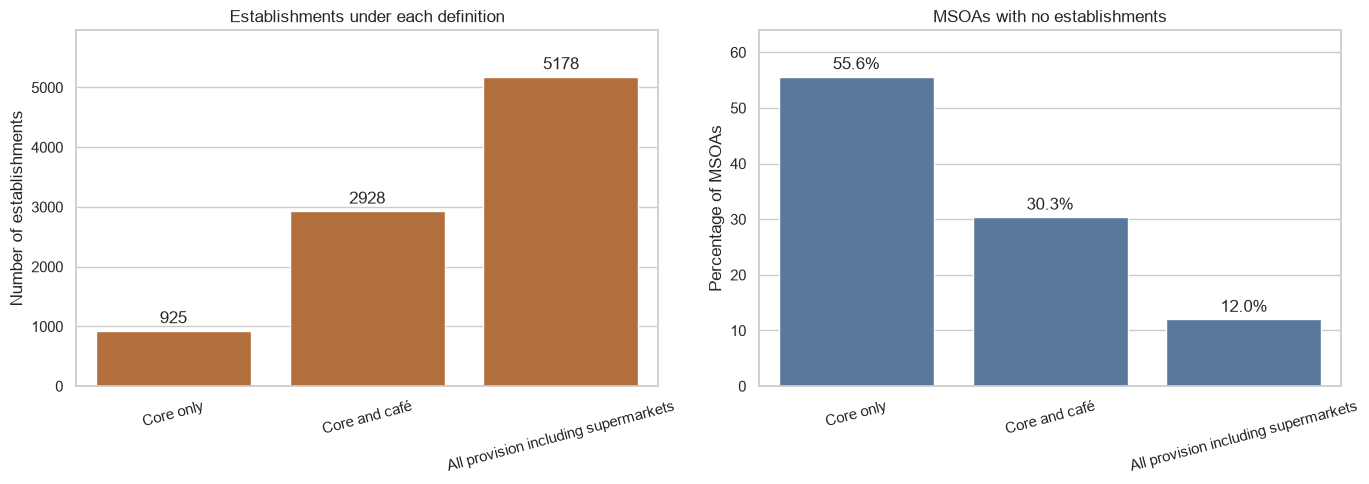

Saved to: ..\outputs\figures\bakery_definition_comparison.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=definition_summary,
            x="Definition",
            y="Establishments",
            color="#c66b2b",
            ax=axes[0])

axes[0].set_title("Establishments under each definition")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of establishments")
axes[0].tick_params(axis="x", rotation=15)
axes[0].margins(y=0.15)

axes[0].bar_label(axes[0].containers[0], fmt="%.0f", padding=3)

sns.barplot(data=definition_summary,
            x="Definition",
            y="Zero MSOAs (%)",
            color="#4c78a8",
            ax=axes[1])

axes[1].set_title("MSOAs with no establishments")
axes[1].set_xlabel("")
axes[1].set_ylabel("Percentage of MSOAs")
axes[1].tick_params(axis="x", rotation=15)
axes[1].margins(y=0.15)

axes[1].bar_label(axes[1].containers[0], fmt="%.1f%%", padding=3)

plt.tight_layout()

definition_figure_path = (FIGURE_FOLDER / "bakery_definition_comparison.png")

plt.savefig(definition_figure_path,  dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {definition_figure_path}")

## Distribution of bakery counts

The distribution of establishment counts is compared across the three cumulative bakery definitions.

Each plot uses their specific horizontal scale since the counts differ substantially between definitions. Values above the 99th percentile are excluded so that the main distributions remain visible.

All MSOAs and their original values remain in the dataset for the later analysis and modelling.

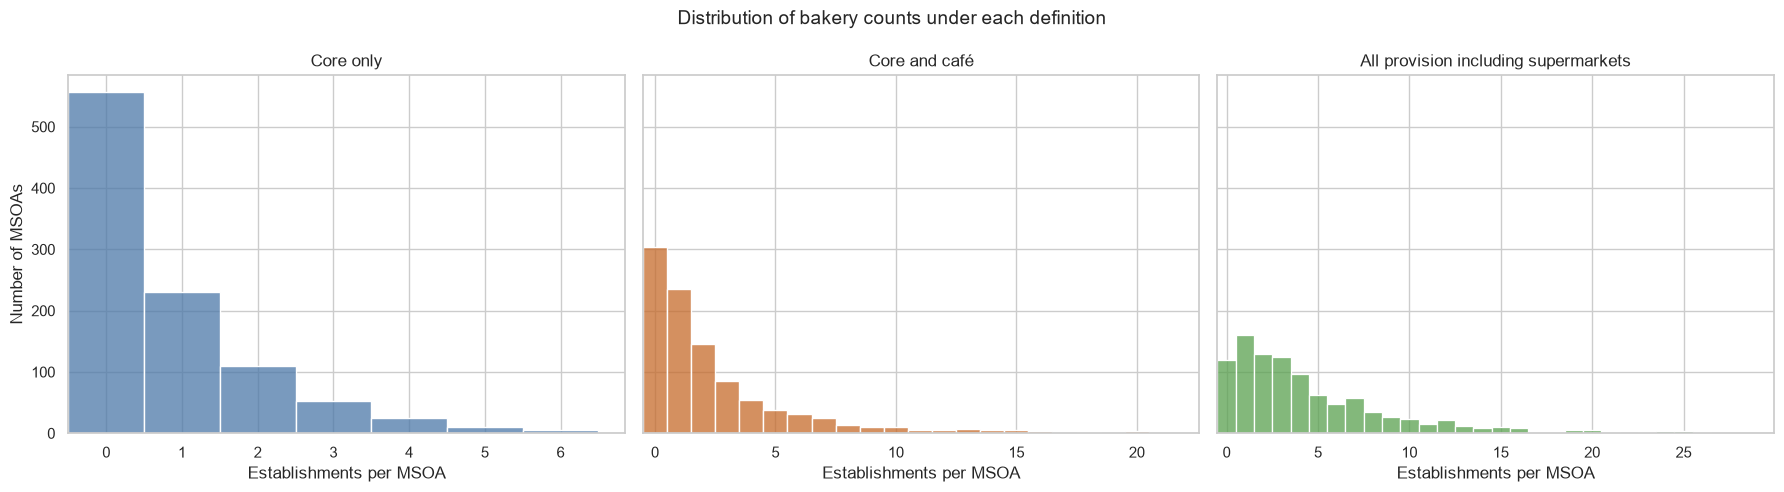

Saved to: ..\outputs\figures\bakery_count_distributions_by_definition.png


In [5]:
distribution_columns = ["core_bakery_count",
                        "core_and_cafe_count",
                        "bakery_count"]

distribution_titles = ["Core only",
                       "Core and café",
                       "All provision including supermarkets"]

distribution_colours = ["#4c78a8",
                        "#c66b2b",
                        "#59a14f"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for axis, column, title, colour in zip(axes, 
                                       distribution_columns,
                                       distribution_titles,
                                       distribution_colours):
        display_limit = (msoa_data[column].quantile(0.99))

        plot_data = msoa_data[msoa_data[column] <= display_limit]

        sns.histplot(data=plot_data,
                     x=column,
                     discrete=True,
                     color=colour,
                     ax=axis)


        axis.set_title(title)
        axis.set_xlabel("Establishments per MSOA")
        axis.set_ylabel("Number of MSOAs")
        axis.set_xlim(left=-0.5)

fig.suptitle("Distribution of bakery counts under each definition", fontsize=14)

plt.tight_layout()

distribution_figure_path = (FIGURE_FOLDER / "bakery_count_distributions_by_definition.png")

plt.savefig(distribution_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {distribution_figure_path}")

# Create table for report

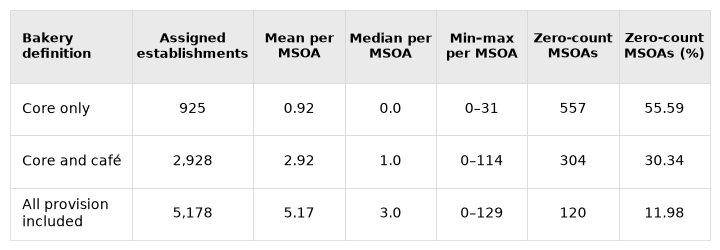

In [10]:
table_definitions = {'Core only': 'core_bakery_count', 
                     'Core and café': 'core_and_cafe_count', 
                     'All provision\nincluded': 'bakery_count'}

table_rows = []

for table_label, table_column in table_definitions.items():

    table_counts = msoa_data[table_column]
    table_rows.append([table_label, 
                       f'{table_counts.sum():,.0f}', 
                       f'{table_counts.mean():.2f}', 
                       f'{table_counts.median():.1f}', 
                       f'{table_counts.min():.0f}–{table_counts.max():.0f}', 
                       f'{table_counts.eq(0).sum():,}', 
                       f'{table_counts.eq(0).mean() * 100:.2f}'])

table_5_5 = pd.DataFrame(table_rows, columns=['Bakery\ndefinition', 
                                              'Assigned\nestablishments', 
                                              'Mean per\nMSOA', 
                                              'Median per\nMSOA', 
                                              'Min–max\nper MSOA', 
                                              'Zero-count\nMSOAs', 
                                              'Zero-count\nMSOAs (%)'])

table_height = 0.8 + 0.5 * len(table_5_5)
table_fig = plt.figure(figsize=(7, table_height), facecolor="white")
table_ax = table_fig.add_axes([0, 0, 1, 1])
table_ax.axis("off")

table_plot = table_ax.table(cellText=table_5_5.values,
                            colLabels=table_5_5.columns,
                            colWidths=[0.20, 0.20, 0.15, 0.15, 0.15, 0.15, 0.15],
                            cellLoc="center",
                            bbox=[0, 0, 1, 1])

table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)

for (table_row, table_col), table_cell in table_plot.get_celld().items():

    table_cell.set_facecolor("white")
    table_cell.set_edgecolor("#D5D5D5")
    table_cell.set_linewidth(0.5)
    table_cell.set_height(0.5 / table_height)
    table_cell.set_text_props(color="black", fontfamily="DejaVu Sans")

    if table_row == 0:
        table_cell.set_facecolor("#EAEAEA")
        table_cell.set_height(0.7 / table_height)
        table_cell.set_text_props(weight="bold", fontsize=9)

    if table_col == 0:
        table_cell.set_text_props(ha="left")

table_folder = Path("../outputs/figures/chapter5_tables")
table_folder.mkdir(parents=True, exist_ok=True)

table_fig.savefig(table_folder / "table_5_5.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
plt.show()
plt.close(table_fig)

## Relationships with population and transport provision

The relationships between bakery counts, resident population and transport provision are compared for all three definitions.

Spearman correlations are used as counts are highly skewed and relationships may not be linear.

Spearman correlations with bakery counts:


,Definition,Population,Transport nodes,Area km2
0,Core only,0.100,0.190,-0.102
1,Core and café,0.118,0.233,-0.176
2,All provision including supermarkets,0.209,0.287,-0.144


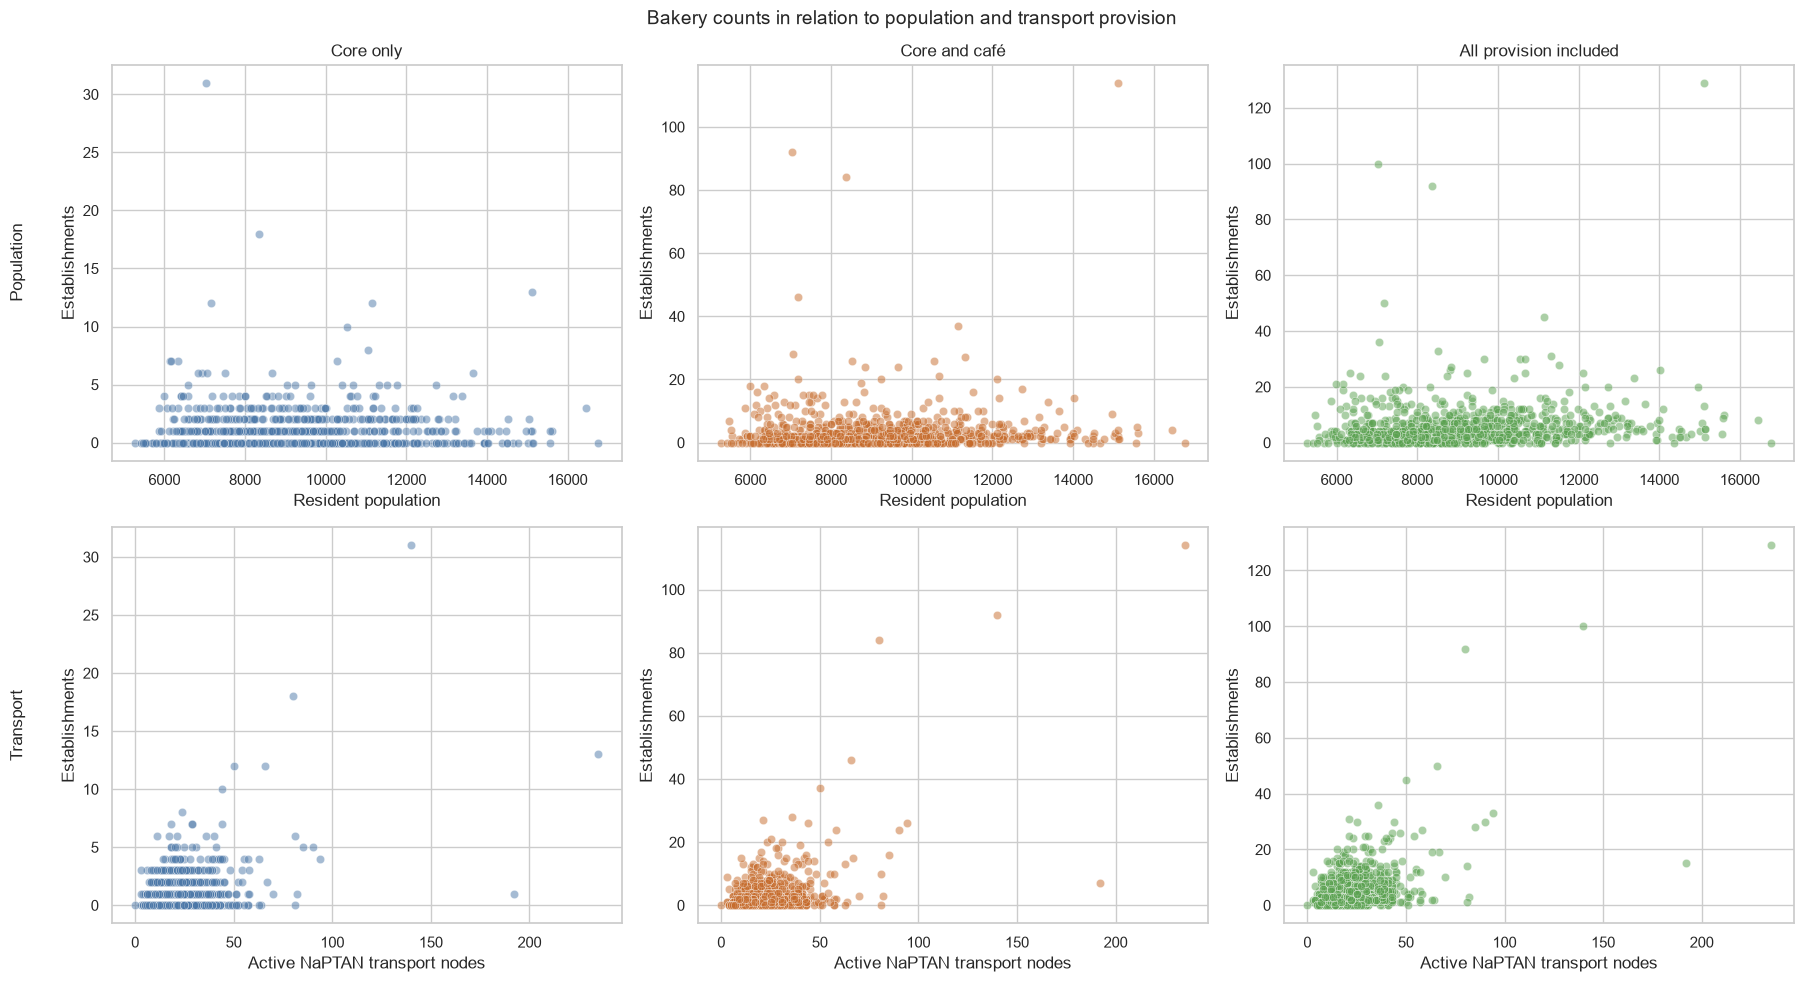

Correlation table saved to: ..\outputs\tables\bakery_definition_correlations_2026-07-23.csv
Figure saved to: ..\outputs\figures\bakery_definition_relationships.png


In [6]:
correlation_rows = []

for definition, count_column, _ in definition_columns:
    correlations = (msoa_data[[count_column,
                               "population",
                               "transport_nodes",
                               "area_km2"]]
                               .corr(method="spearman")
                               .loc[count_column])

    correlation_rows.append({"Definition": definition,
                             "Population": correlations["population"],
                             "Transport nodes": correlations["transport_nodes"],
                             "Area km2": correlations["area_km2"]})

definition_correlations = (pd.DataFrame(correlation_rows).round(3))

print("Spearman correlations with bakery counts:")
display(definition_correlations)

correlation_path = (TABLE_FOLDER / f"bakery_definition_correlations_{DATA_DATE}.csv")
definition_correlations.to_csv(correlation_path, index=False, encoding="utf-8-sig")

scatter_definitions = [("Core only",
                        "core_bakery_count",
                        "#4c78a8"),
                       ("Core and café",
                        "core_and_cafe_count",
                        "#c66b2b"),
                      ("All provision included",
                       "bakery_count",
                       "#59a14f")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex="row", sharey="col")

for position, (title, count_column, colour) in enumerate(scatter_definitions):
    sns.scatterplot(data=msoa_data,
                    x="population",
                    y=count_column,
                    alpha=0.5,
                    color=colour,
                    ax=axes[0, position])

    axes[0, position].set_title(title)
    axes[0, position].set_xlabel("Resident population")
    axes[0, position].set_ylabel("Establishments")

    sns.scatterplot(data=msoa_data,
                    x="transport_nodes",
                    y=count_column,
                    alpha=0.5,
                    color=colour,
                    ax=axes[1, position])

    axes[1, position].set_xlabel("Active NaPTAN transport nodes")
    axes[1, position].set_ylabel("Establishments")

axes[0, 0].text(-0.2, 0.5, "Population",
                transform=axes[0, 0].transAxes,
                rotation=90,
                va="center",
                fontsize=12)

axes[1, 0].text(-0.2, 0.5,"Transport",
                transform=axes[1, 0].transAxes,
                rotation=90,
                va="center",
                fontsize=12)

fig.suptitle("Bakery counts in relation to population and transport provision", fontsize=14)

plt.tight_layout()

relationship_path = (FIGURE_FOLDER / "bakery_definition_relationships.png")
plt.savefig(relationship_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Correlation table saved to: {correlation_path}")
print(f"Figure saved to: {relationship_path}")

## Spatial distribution of bakery counts

Raw establishment counts are mapped for all three bakery definitions.

Each map uses a separate colour scale capped at its own 95th percentile.

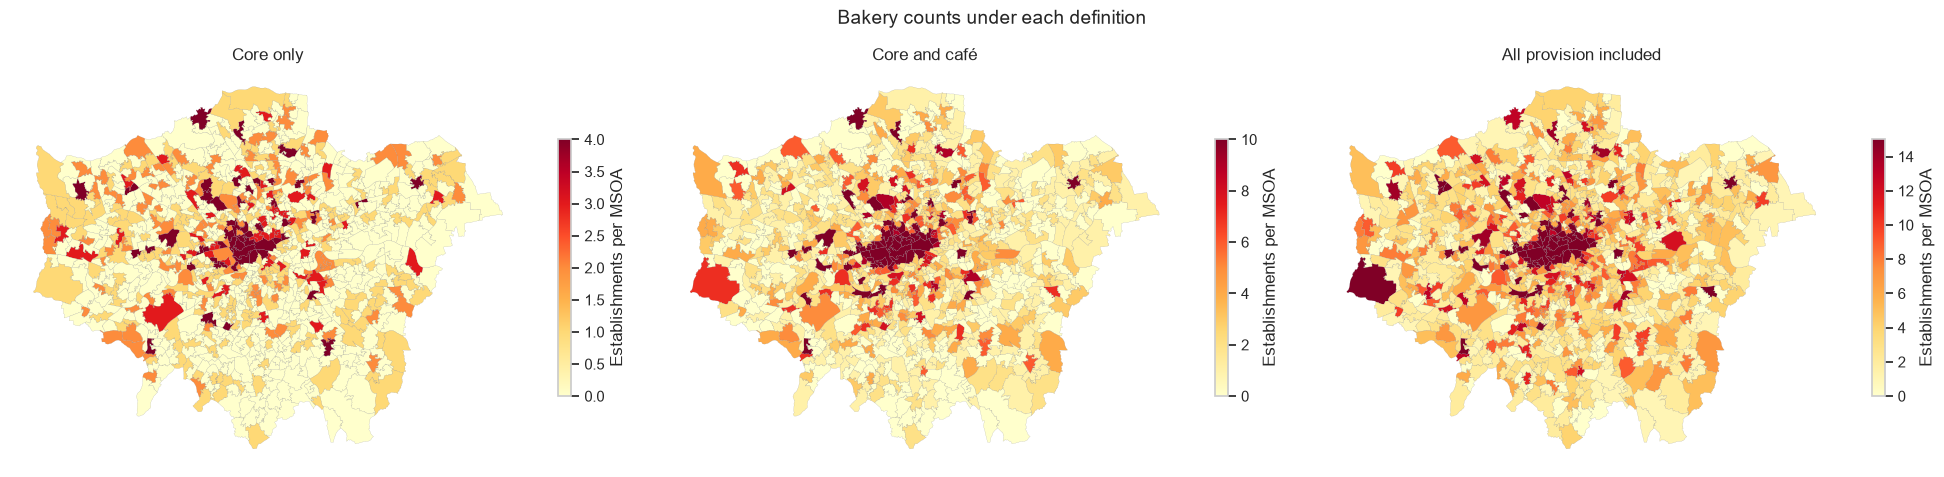

Saved to: ..\outputs\figures\bakery_count_maps_by_definition.png


In [7]:
count_map_definitions = [("core_bakery_count", "Core only"),
                         ("core_and_cafe_count", "Core and café"),
                         ("bakery_count", "All provision included")]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for axis, (column, title) in zip(axes, count_map_definitions):
    map_limit = (msoa_map[column].quantile(0.95))

    msoa_map.plot(column=column,
                   cmap="YlOrRd",
                   linewidth=0.1,
                   edgecolor="grey",
                   vmin=0,
                   vmax=map_limit,
                   legend=True,
                   legend_kwds={"label": "Establishments per MSOA",
                                "shrink": 0.6},
                   ax=axis)

    axis.set_title(title)
    axis.axis("off")

fig.suptitle("Bakery counts under each definition", fontsize=14)

plt.tight_layout()

count_map_path = (FIGURE_FOLDER / "bakery_count_maps_by_definition.png")
plt.savefig(count_map_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {count_map_path}")

Standardised scale maps are produced for the report.

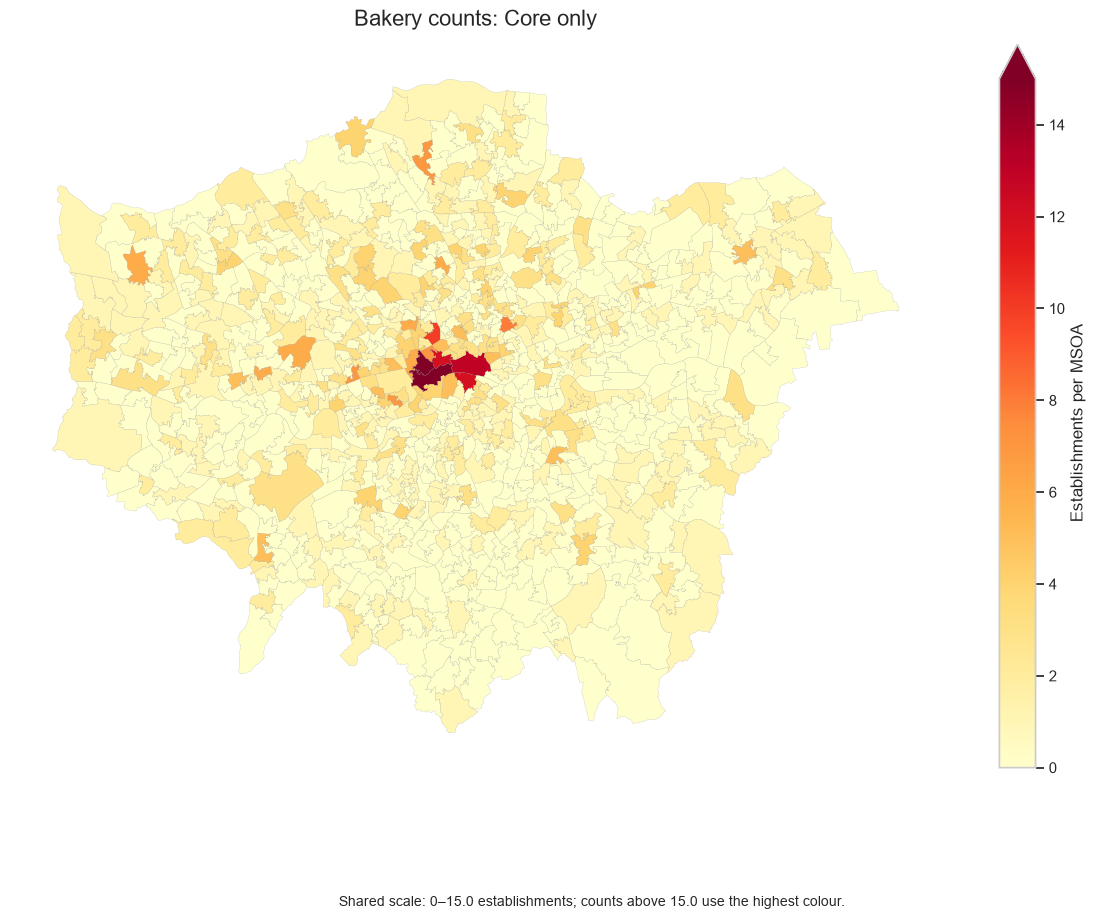

Saved: ..\outputs\figures\bakery_counts_under_each_definition_standard_scale\01_core_only.png


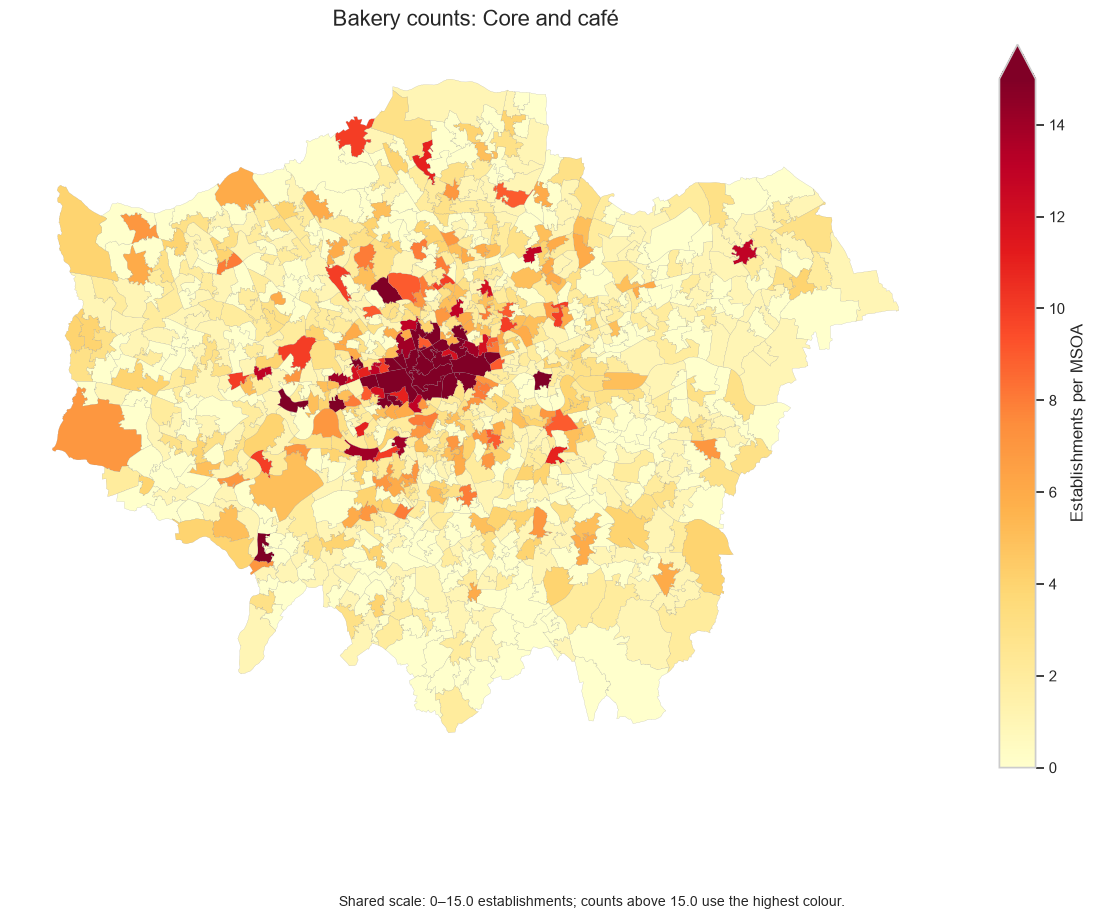

Saved: ..\outputs\figures\bakery_counts_under_each_definition_standard_scale\02_core_and_cafe.png


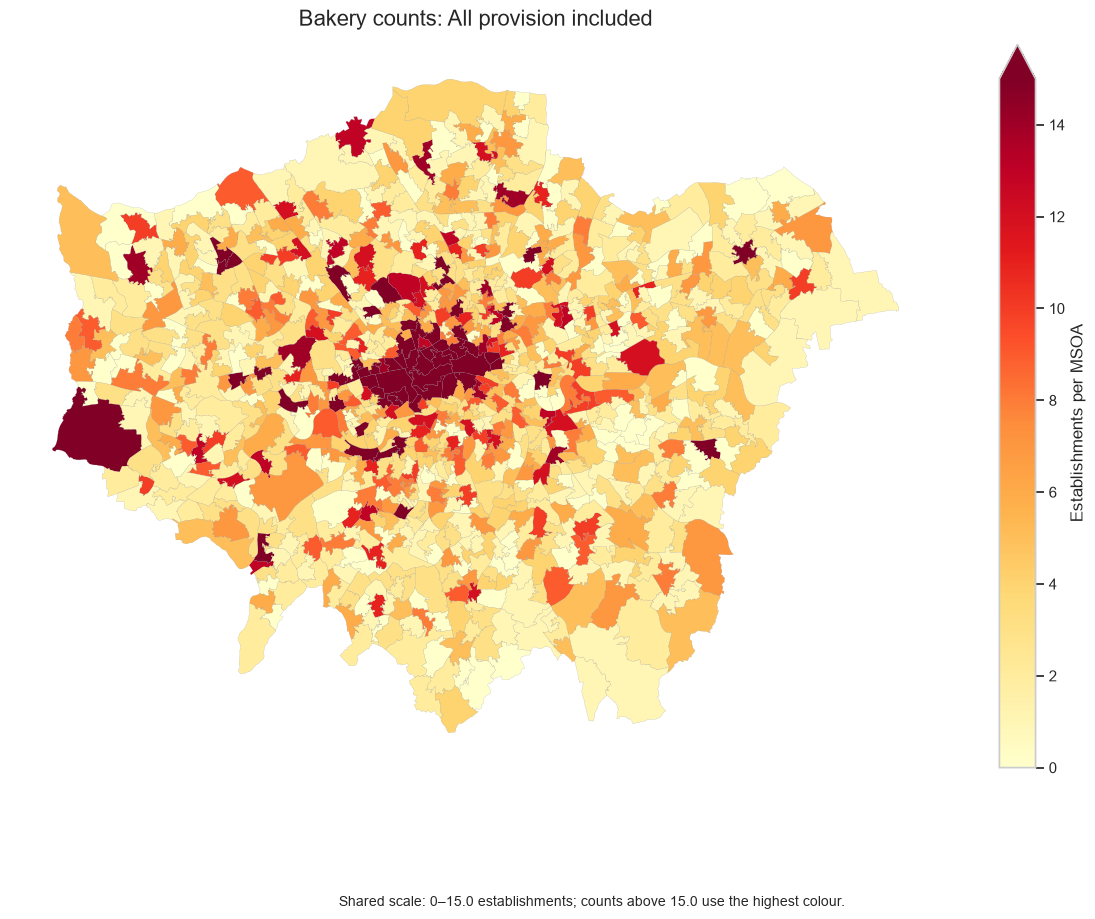

Saved: ..\outputs\figures\bakery_counts_under_each_definition_standard_scale\03_all_provision.png


In [8]:
standard_count_folder = (FIGURE_FOLDER / "bakery_counts_under_each_definition_standard_scale")
standard_count_folder.mkdir(parents=True, exist_ok=True)

count_maps = [("core_bakery_count", "Core only", "01_core_only.png"),
              ("core_and_cafe_count", "Core and café", "02_core_and_cafe.png"),
              ("bakery_count", "All provision included", "03_all_provision.png"),]

# One shared colour scale, based on the broadest definition.
shared_max = max(1, msoa_map["bakery_count"].quantile(0.95))

for column, title, filename in count_maps:
    fig, ax = plt.subplots(figsize=(12, 10))

    msoa_map.plot(column=column,
                  cmap="YlOrRd",
                  linewidth=0.1,
                  edgecolor="grey",
                  vmin=0,
                  vmax=shared_max,
                  legend=True,
                  legend_kwds={"label": "Establishments per MSOA",
                               "shrink": 0.8,
                               "extend": "max"},
                  ax=ax)

    ax.set_title(f"Bakery counts: {title}", fontsize=16, pad=15)
    ax.axis("off")

    fig.text(0.5, 0.03,
             f"Shared scale: 0–{shared_max} establishments; counts above {shared_max} use the highest colour.",
             ha="center",
             fontsize=10)

    fig.tight_layout(rect=[0, 0.06, 1, 1])

    output_path = standard_count_folder / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {output_path}")

## Bakery provision per 10,000 residents

Per-capita provision is calculated to account for differences in resident population between MSOAs.

The maps show the number of establishments per 10,000 residents under each definition.

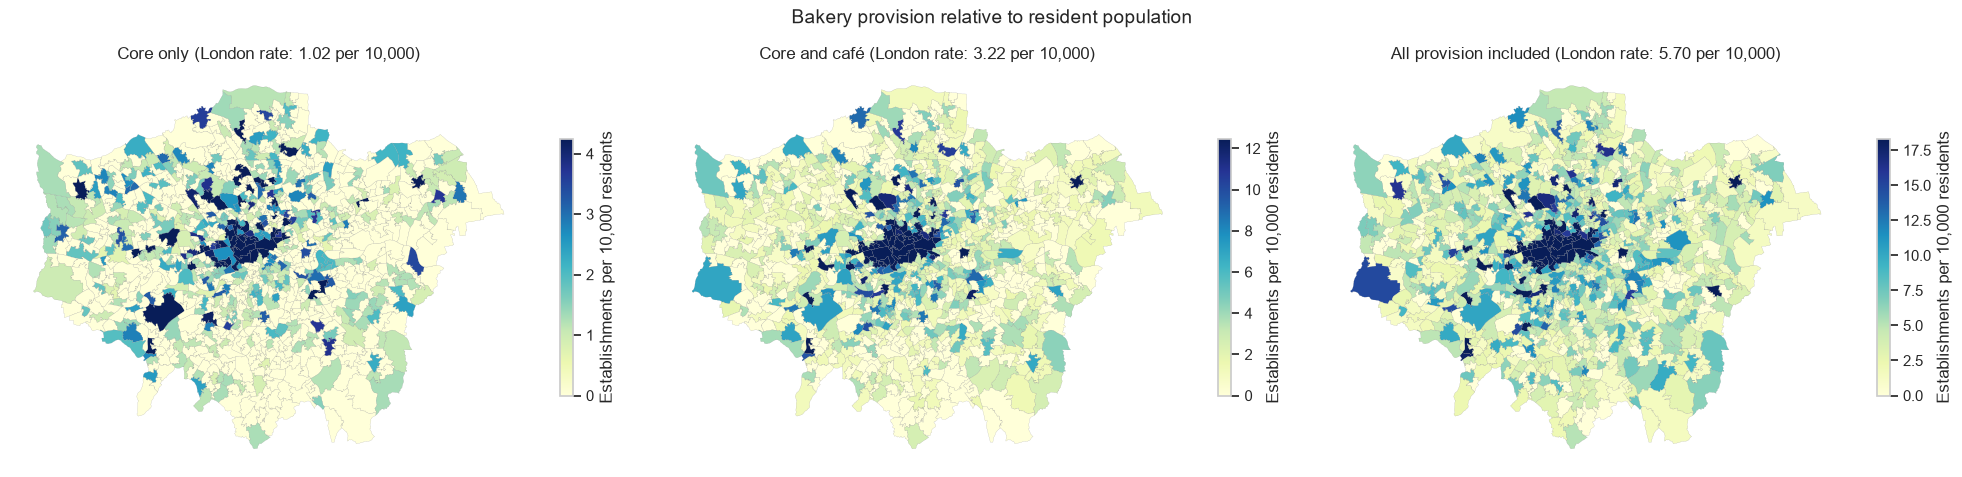

Saved to: ..\outputs\figures\bakery_per_capita_maps_by_definition.png


In [9]:
london_rate_lookup = (definition_summary
                      .set_index("Definition")["London rate per 10,000"]
                      .to_dict())

rate_map_definitions = [("core_bakeries_per_10000_people",
                         "Core only",
                         "Core only"),
                        ("core_and_cafe_per_10000_people",
                         "Core and café",
                         "Core and café"),
                        ("bakeries_per_10000_people",
                         "All provision included",
                         "All provision including supermarkets")]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for axis, (column, title, definition) in zip(axes, rate_map_definitions):
    map_limit = (msoa_map[column].quantile(0.95))

    london_rate = london_rate_lookup[definition]

    msoa_map.plot(column=column,
                  cmap="YlGnBu",
                  linewidth=0.1,
                  edgecolor="grey",
                  vmin=0,
                  vmax=map_limit,
                  legend=True,
                  legend_kwds={"label": "Establishments per 10,000 residents",
                               "shrink": 0.6},
                  ax=axis)

    axis.set_title(f"{title} (London rate: {london_rate:.2f} per 10,000)")
    axis.axis("off")

fig.suptitle("Bakery provision relative to resident population", fontsize=14)

plt.tight_layout()

per_capita_map_path = (FIGURE_FOLDER / "bakery_per_capita_maps_by_definition.png")
plt.savefig(per_capita_map_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {per_capita_map_path}")

## Bakery provision per square kilometre

Bakery density provides a second descriptive baseline by accounting for differences in MSOA area.

High bakery density indicates that establishments are spatially concentrated within an MSOA.

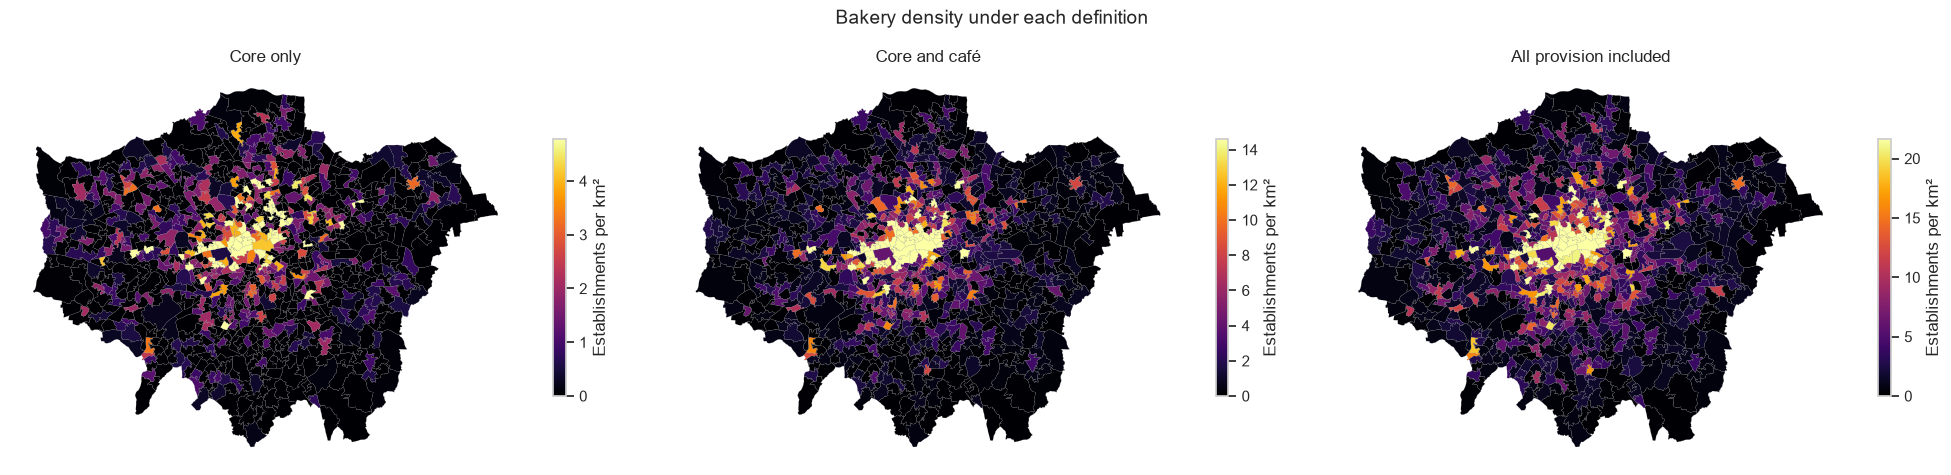

Saved to: ..\outputs\figures\bakery_density_maps_by_definition.png


In [10]:
density_map_definitions = [("core_bakery_density_km2", "Core only"),
                           ("core_and_cafe_density_km2", "Core and café"),
                           ("bakery_density_km2", "All provision included")]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for axis, (column, title) in zip(axes, density_map_definitions):
    map_limit = (msoa_map[column].quantile(0.95))

    msoa_map.plot(column=column,
                  cmap="inferno",
                  linewidth=0.1, 
                  edgecolor="grey",
                  vmin=0,
                  vmax=map_limit,
                  legend=True,
                  legend_kwds={"label": "Establishments per km²",
                               "shrink": 0.6},
                  ax=axis)

    axis.set_title(title)
    axis.axis("off")

fig.suptitle("Bakery density under each definition", fontsize=14)

plt.tight_layout()

density_map_path = (FIGURE_FOLDER / "bakery_density_maps_by_definition.png")
plt.savefig(density_map_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {density_map_path}")

## Contribution of the additional bakery classes

The cumulative definitions isolate the establishments added at each stage. The difference between the core-and-café and core-only counts represents establishments classified as `BAKERY_CAFE`. The difference between the all-included-provision and core-and-café counts represents establishments classified as `GROCER_BAKERY`.

,Class,Establishments,MSOAs represented,Share of all provision (%)
0,Core bakeries,925,445,17.86
1,Bakery cafés,2003,578,38.68
2,Grocer and supermarket bakeries,2250,778,43.45


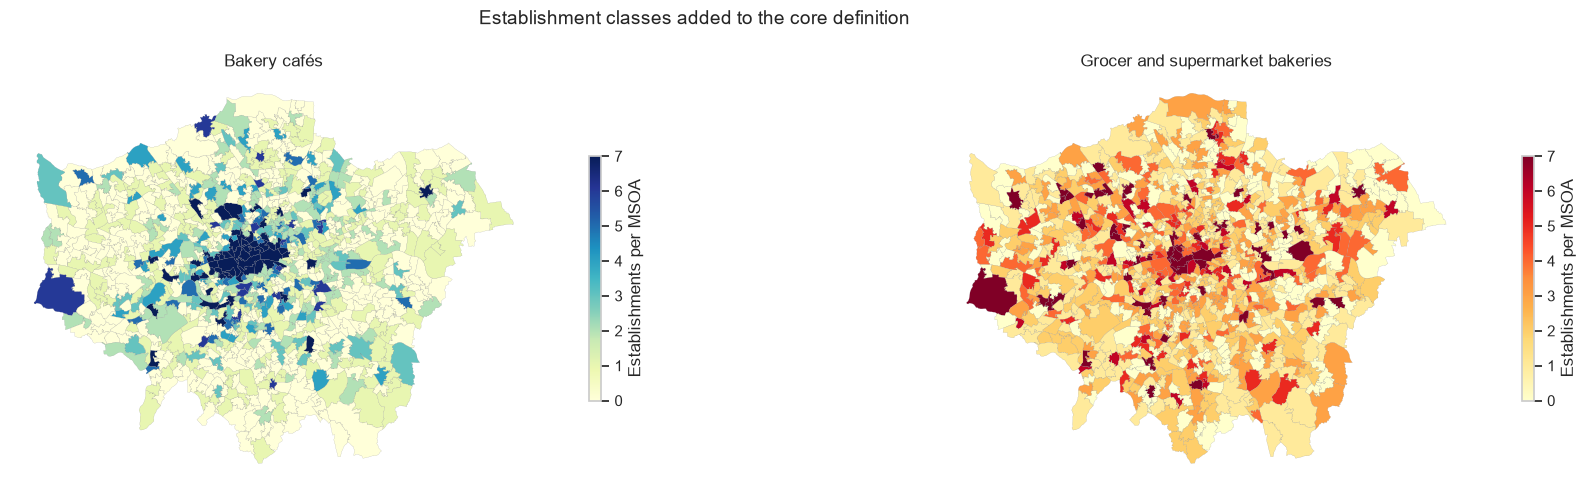

Summary saved to: ..\outputs\tables\bakery_class_layer_summary_2026-07-23.csv
Figure saved to: ..\outputs\figures\additional_bakery_class_maps.png


In [11]:
# Isolate the classes added to the core definition
msoa_data["bakery_cafe_only_count"
          ] = (msoa_data["core_and_cafe_count"] - msoa_data["core_bakery_count"])

msoa_data["grocer_bakery_only_count"
          ] = (msoa_data["bakery_count"] - msoa_data["core_and_cafe_count"])

msoa_map["bakery_cafe_only_count"
         ] = (msoa_map["core_and_cafe_count"] - msoa_map["core_bakery_count"])

msoa_map["grocer_bakery_only_count"
         ] = (msoa_map["bakery_count"] - msoa_map["core_and_cafe_count"])

class_layer_summary = pd.DataFrame(
    {"Class": ["Core bakeries", "Bakery cafés", "Grocer and supermarket bakeries"],
    "Establishments": [msoa_data["core_bakery_count"].sum(),
                       msoa_data["bakery_cafe_only_count"].sum(),
                       msoa_data["grocer_bakery_only_count"].sum()],
    "MSOAs represented": [msoa_data["core_bakery_count"].gt(0).sum(),
                          msoa_data["bakery_cafe_only_count"].gt(0).sum(),
                          msoa_data["grocer_bakery_only_count"].gt(0).sum()]})

class_layer_summary["Share of all provision (%)"
                    ] = (class_layer_summary["Establishments"] / msoa_data["bakery_count"].sum() * 100).round(2)

display(class_layer_summary)

class_layer_path = (TABLE_FOLDER / f"bakery_class_layer_summary_{DATA_DATE}.csv")
class_layer_summary.to_csv(class_layer_path, index=False, encoding="utf-8-sig")

addition_maps = [("bakery_cafe_only_count", "Bakery cafés", "YlGnBu"),
                 ("grocer_bakery_only_count", "Grocer and supermarket bakeries", "YlOrRd")]

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

for axis, (column, title, colour_map) in zip(axes, addition_maps):
    map_limit = (msoa_map[column].quantile(0.95))

    msoa_map.plot(column=column,
                  cmap=colour_map,
                  linewidth=0.1,
                  edgecolor="grey",
                  vmin=0,
                  vmax=map_limit,
                  legend=True,
                  legend_kwds={"label": "Establishments per MSOA", 
                               "shrink": 0.6},
                  ax=axis)

    axis.set_title(title)
    axis.axis("off")

fig.suptitle("Establishment classes added to the core definition", fontsize=14)

plt.tight_layout()
addition_map_path = (FIGURE_FOLDER / "additional_bakery_class_maps.png")
plt.savefig(addition_map_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Summary saved to: {class_layer_path}")
print(f"Figure saved to: {addition_map_path}")

## Summary and next step

The definitions differ in establishment totals, number of zero-count MSOAs, dispersion, relationships with population/transport provision, and spatial patterns. All three definitions are being explored and modelled but the later analysis treats core bakeries and bakery cafés as the primary definition, with core-only and all-provision results retained as strict and broad sensitivity analyses.

All three outcomes are overdispersed but the Poisson regression will be used as the initial count-model baseline, followed by Negative Binomial regression. The same predictors and general model specification will be applied to each definition so differences in expected provision and under-provision ranks can be attributed primarily to the bakery definition used.